# Recoverability Boundary — Minimal Redox–Bioenergetic Model

This notebook reproduces the main computational results associated with the manuscript:

**A recoverability boundary in a minimal rate-limited dynamical system**  
Jaime Ojeda (2026)

It is organized into four blocks:

1. Minimal baseline recovery model  
2. Extended redox–bioenergetic model  
3. Recoverability boundary and robustness  
4. History-dependent recoverability under double-pulse forcing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from dataclasses import dataclass

SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 1. Minimal baseline recovery model

The base layer contains two variables:

- `E(t)`: effective energy capacity  
- `U(t)`: usable recovery capacity  

This layer is used only to establish a stable baseline before adding oxidative burden.

In [2]:
@dataclass
class BaseParams:
    # tiempo
    T: float = 20.0
    dt: float = 0.01

    # estado inicial
    E0: float = 1.0
    U0: float = 1.0

    # dinámica
    k_prod: float = 1.0
    k_dem: float = 1.2
    k_rec: float = 0.6

    # thresholds operativos
    return_tol: float = 0.90
    collapse_threshold: float = 0.35

    # forcing
    pulse_center: float = 4.0

In [3]:
def gaussian_forcing(t, auc, width, center):
    width = max(width, 1e-4)
    amp = auc / (np.sqrt(2 * np.pi) * width)
    return amp * np.exp(-0.5 * ((t - center) / width) ** 2)

In [4]:
def base_system(t, y, params, auc, width):
    E, U = y

    D = gaussian_forcing(t, auc=auc, width=width, center=params.pulse_center)

    dE_dt = params.k_prod * (U - E) - params.k_dem * D
    dU_dt = params.k_rec * (1.0 - U)

    return [dE_dt, dU_dt]

In [5]:
def simulate_base(params, auc, width):
    t_eval = np.linspace(0, params.T, int(params.T / params.dt) + 1)

    sol = solve_ivp(
        fun=lambda t, y: base_system(t, y, params, auc, width),
        t_span=(0, params.T),
        y0=[params.E0, params.U0],
        t_eval=t_eval,
        method="RK45"
    )

    t = sol.t
    E = sol.y[0]
    U = sol.y[1]
    D = gaussian_forcing(t, auc=auc, width=width, center=params.pulse_center)

    # clip suave para interpretación física
    E = np.clip(E, 0.0, None)
    U = np.clip(U, 0.0, 1.2)

    return t, D, E, U

In [6]:
def extract_base_metrics(t, E, U, return_tol=0.90, collapse_threshold=0.35):
    baseline_E = E[0]

    E_min = float(np.min(E))
    min_idx = int(np.argmin(E))

    collapsed = bool(E_min <= collapse_threshold * baseline_E)
    collapse_time = float(t[min_idx]) if collapsed else np.nan

    return_idx = None
    for i in range(min_idx, len(E)):
        if E[i] >= return_tol * baseline_E:
            return_idx = i
            break

    returned = return_idx is not None
    tau_return = float(t[return_idx] - t[min_idx]) if returned else np.nan

    final_E = float(np.mean(E[-50:]))
    final_U = float(np.mean(U[-50:]))

    return {
        "E_min": E_min,
        "collapsed": collapsed,
        "collapse_time": collapse_time,
        "returned": returned,
        "tau_return": tau_return,
        "final_E": final_E,
        "final_U": final_U,
    }

In [7]:
params = BaseParams()
t, D, E, U = simulate_base(params, auc=1.0, width=0.4)

metrics_base = extract_base_metrics(
    t, E, U,
    return_tol=params.return_tol,
    collapse_threshold=params.collapse_threshold
)

print(metrics_base)

{'E_min': 0.3669078127653539, 'collapsed': False, 'collapse_time': nan, 'returned': True, 'tau_return': 2.12, 'final_E': 0.9999345560390401, 'final_U': 1.0}


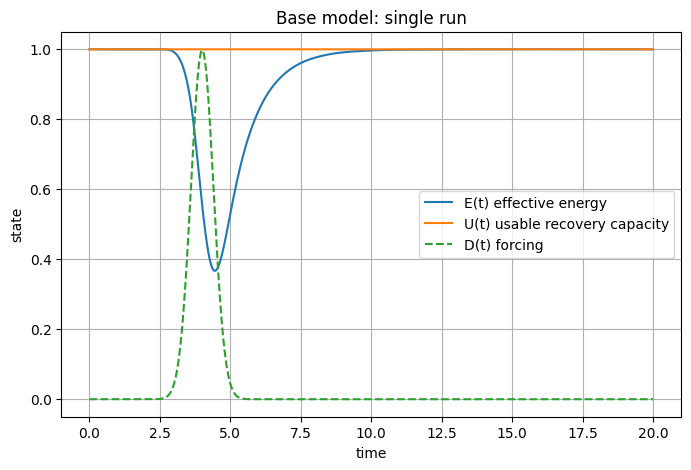

In [8]:
plt.plot(t, E, label="E(t) effective energy")
plt.plot(t, U, label="U(t) usable recovery capacity")
plt.plot(t, D, label="D(t) forcing", linestyle="--")

plt.xlabel("time")
plt.ylabel("state")
plt.title("Base model: single run")
plt.legend()
plt.show()

## 2. Extended redox–bioenergetic model

The extended model introduces three variables:

- `E(t)`: effective energetic capacity  
- `R(t)`: oxidative burden / damage load  
- `U(t)`: usable recovery capacity  

This is the main model used for the paper results.

In [9]:
@dataclass
class DamageParams:
    # tiempo
    T: float = 20.0
    dt: float = 0.01

    # estado inicial
    E0: float = 1.0
    R0: float = 0.0
    U0: float = 1.0

    # dinámica energética
    k_prod: float = 1.0
    k_dem: float = 1.2
    k_loss: float = 0.25

    # dinámica ROS / daño
    k_ros: float = 0.20
    k_clear: float = 0.60
    eps: float = 0.05

    # dinámica de capacidad usable
    k_rec: float = 0.40
    k_inj: float = 0.50

    # thresholds operativos
    return_tol: float = 0.90
    collapse_threshold: float = 0.35

    # forcing
    pulse_center: float = 4.0

In [10]:
def damage_system(t, y, params, auc, width):
    E, R, U = y

    D = gaussian_forcing(t, auc=auc, width=width, center=params.pulse_center)

    dE_dt = params.k_prod * (U - E) - params.k_dem * D - params.k_loss * R
    dR_dt = params.k_ros * D / (E + params.eps) - params.k_clear * R
    dU_dt = params.k_rec * (1.0 - U) - params.k_inj * R * U

    return [dE_dt, dR_dt, dU_dt]

In [11]:
def simulate_damage(params, auc, width):
    t_eval = np.linspace(0, params.T, int(params.T / params.dt) + 1)

    sol = solve_ivp(
        fun=lambda t, y: damage_system(t, y, params, auc, width),
        t_span=(0, params.T),
        y0=[params.E0, params.R0, params.U0],
        t_eval=t_eval,
        method="RK45"
    )

    t = sol.t
    E = sol.y[0]
    R = sol.y[1]
    U = sol.y[2]
    D = gaussian_forcing(t, auc=auc, width=width, center=params.pulse_center)

    # clip suave para interpretación
    E = np.clip(E, 0.0, None)
    R = np.clip(R, 0.0, None)
    U = np.clip(U, 0.0, 1.2)

    return t, D, E, R, U

In [12]:
dparams = DamageParams()

t2, D2, E2, R2, U2 = simulate_damage(dparams, auc=1.0, width=0.4)

metrics_damage = extract_base_metrics(
    t2, E2, U2,
    return_tol=dparams.return_tol,
    collapse_threshold=dparams.collapse_threshold
)

print(metrics_damage)

{'E_min': 0.331292347307546, 'collapsed': True, 'collapse_time': 4.49, 'returned': True, 'tau_return': 4.710000000000001, 'final_E': 0.9975195073418296, 'final_U': 0.9984854798931402}


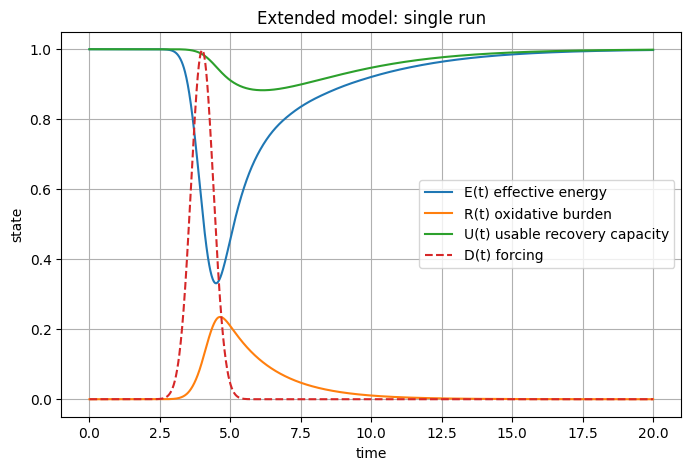

In [13]:
plt.plot(t2, E2, label="E(t) effective energy")
plt.plot(t2, R2, label="R(t) oxidative burden")
plt.plot(t2, U2, label="U(t) usable recovery capacity")
plt.plot(t2, D2, label="D(t) forcing", linestyle="--")

plt.xlabel("time")
plt.ylabel("state")
plt.title("Extended model: single run")
plt.legend()
plt.show()

### Same AUC, different timescale

This comparison illustrates that matched total load can still produce different outcomes depending on forcing width.

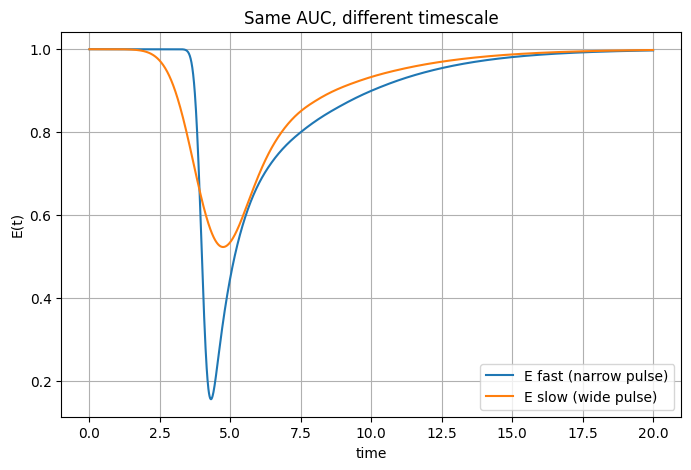

FAST: {'E_min': 0.15524838625142331, 'collapsed': True, 'collapse_time': 4.3100000000000005, 'returned': True, 'tau_return': 5.709999999999999, 'final_E': 0.9968255207594384, 'final_U': 0.9980614992714334}
SLOW: {'E_min': 0.5225957938183202, 'collapsed': False, 'collapse_time': nan, 'returned': True, 'tau_return': 3.9499999999999993, 'final_E': 0.9978980633092784, 'final_U': 0.9987159712092227}


In [14]:
auc = 1.0
width_fast = 0.2
width_slow = 0.8

t_f, D_f, E_f, R_f, U_f = simulate_damage(dparams, auc, width_fast)
t_s, D_s, E_s, R_s, U_s = simulate_damage(dparams, auc, width_slow)

plt.plot(t_f, E_f, label="E fast (narrow pulse)")
plt.plot(t_s, E_s, label="E slow (wide pulse)")
plt.xlabel("time")
plt.ylabel("E(t)")
plt.title("Same AUC, different timescale")
plt.legend()
plt.show()

m_fast = extract_base_metrics(t_f, E_f, U_f)
m_slow = extract_base_metrics(t_s, E_s, U_s)

print("FAST:", m_fast)
print("SLOW:", m_slow)

## 3. Recoverability boundary and robustness

In [15]:
def compute_phase_map(params, aucs, widths):
    results = []

    for auc in aucs:
        for width in widths:
            t, D, E, R, U = simulate_damage(params, auc, width)
            m = extract_base_metrics(t, E, U)

            results.append({
                "auc": auc,
                "width": width,
                "collapsed": m["collapsed"]
            })

    df = pd.DataFrame(results)
    pivot = df.pivot(index="width", columns="auc", values="collapsed")

    return df, pivot

In [16]:
aucs_fine = np.linspace(0.7, 1.4, 30)
widths_fine = np.linspace(0.2, 1.0, 30)

df_base, pivot_base = compute_phase_map(dparams, aucs_fine, widths_fine)

In [17]:
def save_figure(name):
    plt.savefig(f"{name}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{name}.pdf", bbox_inches="tight")

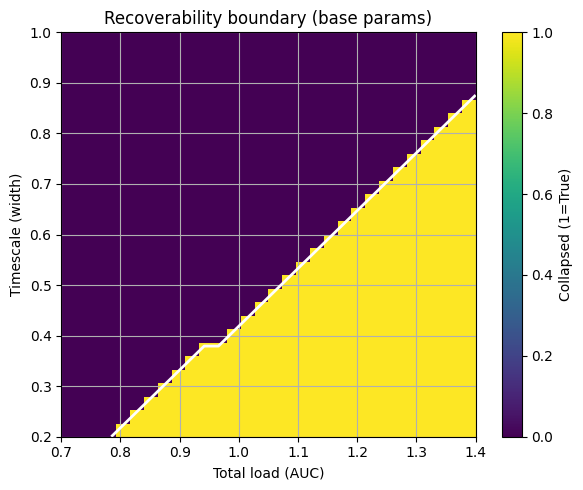

In [18]:
plt.figure(figsize=(6,5))

plt.imshow(
    pivot_base.values,
    origin="lower",
    aspect="auto",
    extent=[aucs_fine.min(), aucs_fine.max(), widths_fine.min(), widths_fine.max()],
    cmap="viridis"
)

plt.colorbar(label="Collapsed (1=True)")

plt.contour(
    aucs_fine,
    widths_fine,
    pivot_base.values,
    levels=[0.5],
    colors="white",
    linewidths=2
)

plt.xlabel("Total load (AUC)")
plt.ylabel("Timescale (width)")
plt.title("Recoverability boundary (base params)")

save_figure("figure_1_boundary")
plt.tight_layout()
plt.show()

In [19]:
dparams_low_clear = DamageParams(k_clear=0.4)
dparams_high_clear = DamageParams(k_clear=0.8)

df_low, pivot_low = compute_phase_map(dparams_low_clear, aucs_fine, widths_fine)
df_high, pivot_high = compute_phase_map(dparams_high_clear, aucs_fine, widths_fine)

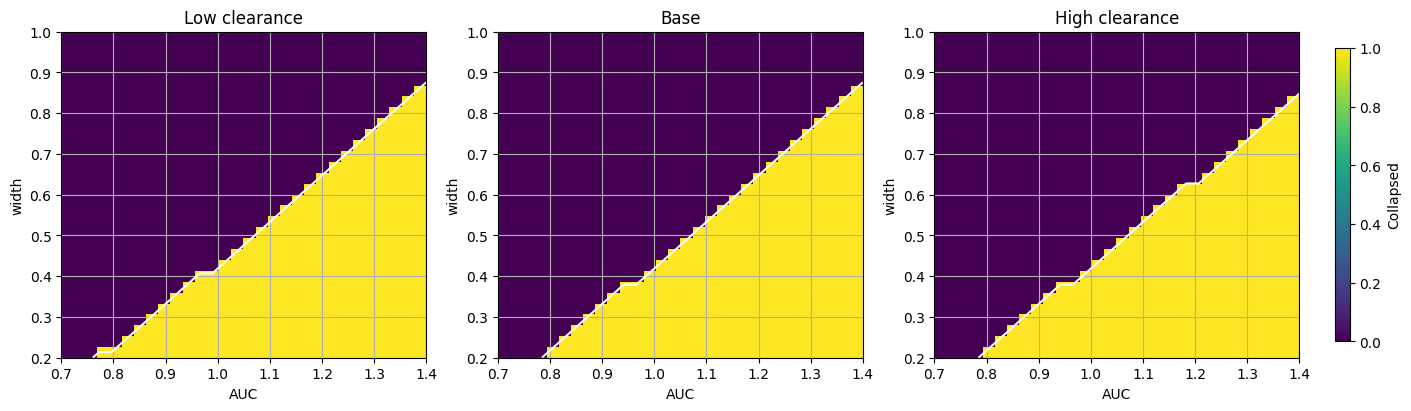

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

titles = ["Low clearance", "Base", "High clearance"]
pivots = [pivot_low, pivot_base, pivot_high]

im = None

for ax, p, title in zip(axs, pivots, titles):
    im = ax.imshow(
        p.values,
        origin="lower",
        aspect="auto",
        extent=[aucs_fine.min(), aucs_fine.max(), widths_fine.min(), widths_fine.max()],
        cmap="viridis"
    )

    ax.contour(
        aucs_fine,
        widths_fine,
        p.values,
        levels=[0.5],
        colors="white",
        linewidths=1.5
    )

    ax.set_title(title)
    ax.set_xlabel("AUC")
    ax.set_ylabel("width")

# colorbar única, fuera de los paneles
cbar = fig.colorbar(im, ax=axs, location="right", shrink=0.9, pad=0.02)
cbar.set_label("Collapsed")

save_figure("figure_2_robustness")
plt.show()

## 4. History-dependent recoverability

The double-pulse experiment uses the **same consistent damage model** and asks whether prior exposure changes the outcome under identical primary forcing.

In [21]:
def double_gaussian_forcing(t, auc1, width1, center1, auc2, width2, center2):
    D1 = gaussian_forcing(t, auc=auc1, width=width1, center=center1)
    D2 = gaussian_forcing(t, auc=auc2, width=width2, center=center2)
    return D1 + D2

In [22]:
def damage_system_double(t, y, params, auc1, width1, center1, auc2, width2, center2):
    E, R, U = y

    D = double_gaussian_forcing(
        t,
        auc1=auc1, width1=width1, center1=center1,
        auc2=auc2, width2=width2, center2=center2
    )

    dE_dt = params.k_prod * (U - E) - params.k_dem * D - params.k_loss * R
    dR_dt = params.k_ros * D / (E + params.eps) - params.k_clear * R
    dU_dt = params.k_rec * (1.0 - U) - params.k_inj * R * U

    return [dE_dt, dR_dt, dU_dt]

In [23]:
def simulate_damage_double(params, auc1, width1, center1, auc2, width2, center2):
    t_eval = np.linspace(0, params.T, int(params.T / params.dt) + 1)

    sol = solve_ivp(
        fun=lambda t, y: damage_system_double(
            t, y, params,
            auc1, width1, center1,
            auc2, width2, center2
        ),
        t_span=(0, params.T),
        y0=[params.E0, params.R0, params.U0],
        t_eval=t_eval,
        method="RK45"
    )

    t = sol.t
    E = np.clip(sol.y[0], 0.0, None)
    R = np.clip(sol.y[1], 0.0, None)
    U = np.clip(sol.y[2], 0.0, 1.2)

    D = double_gaussian_forcing(
        t,
        auc1=auc1, width1=width1, center1=center1,
        auc2=auc2, width2=width2, center2=center2
    )

    return t, D, E, R, U

In [24]:
final_params = DamageParams(
    k_prod=1.0,
    k_dem=1.2,
    k_loss=0.25,
    k_ros=0.20,
    k_clear=0.60,
    eps=0.05,
    k_rec=0.40,
    k_inj=0.50
)

In [25]:
# No pre-pulse
t0, D0, E0, R0, U0 = simulate_damage_double(
    final_params,
    auc1=0.0, width1=0.3, center1=4.0,
    auc2=1.0, width2=0.4, center2=7.0
)

# With pre-pulse
t1, D1, E1, R1, U1 = simulate_damage_double(
    final_params,
    auc1=0.5, width1=0.3, center1=4.0,
    auc2=1.0, width2=0.4, center2=7.0
)

m0 = extract_base_metrics(t0, E0, U0)
m1 = extract_base_metrics(t1, E1, U1)

print("NO pre-pulse:", m0)
print("WITH pre-pulse:", m1)

NO pre-pulse: {'E_min': 0.9997078364740482, 'collapsed': False, 'collapse_time': nan, 'returned': True, 'tau_return': 0.0, 'final_E': 0.9999015310174936, 'final_U': 1.0000003244926525}
WITH pre-pulse: {'E_min': 0.26287158842315, 'collapsed': True, 'collapse_time': 7.49, 'returned': True, 'tau_return': 5.49, 'final_E': 0.9902905798180655, 'final_U': 0.9939865752521491}


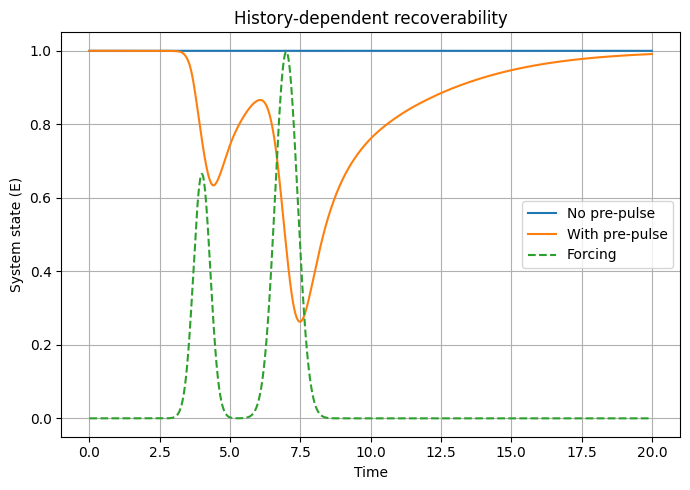

In [26]:
plt.figure(figsize=(7,5))
plt.plot(t0, E0, label="No pre-pulse")
plt.plot(t1, E1, label="With pre-pulse")
plt.plot(t1, D1, linestyle="--", label="Forcing")

plt.xlabel("Time")
plt.ylabel("System state (E)")
plt.title("History-dependent recoverability")

plt.legend()
save_figure("figure_3_history")
plt.tight_layout()
plt.show()

## 5. Export tables (optional)

These exports can be used to support the manuscript or to populate the repository.

In [27]:
df_base.to_csv("phase_map_base.csv", index=False)
df_low.to_csv("phase_map_low_clear.csv", index=False)
df_high.to_csv("phase_map_high_clear.csv", index=False)

print("Saved phase-map tables and figure files.")

Saved phase-map tables and figure files.
